# Rare Earth Element (REE) Anomaly Detection Using Machine Learning

## Objective

The objective of this analysis is to identify anomalous REE geochemical samples using unsupervised machine learning techniques.

The workflow includes:
- REE feature selection
- Data quality assessment
- Treatment of zero and non-positive values
- Missing-value imputation
- Centered Log-Ratio (CLR) transformation
- Feature scaling
- Anomaly detection using Isolation Forest, LOF, and One-Class SVM
- Model comparison
- Investigation of LOF-only anomalies
- Local geochemical interpretation using neighboring samples

In [1]:
import pandas as pd

## 1. Load and Explore the Dataset

First, the geochemical dataset is loaded and its structure is examined to understand the available samples, variables, and REE-related information.

In [2]:
df = pd.read_excel('Geochemical data_GIS/NGCM-Stream-Sediment-Analysis-Updated.xlsx')

In [3]:
df.head()

,FID,Shape *,gid,objectid,sampleno,X,Y,Si02_%,Al2O3_%,Fe2O3_%,...,Ta_ppm,W_ppm,U_ppm,Pt_ppb,Pd_ppb,In_ppm,F_ppm,Te_ppm,Tl_ppm,toposheet
0,0,Point,129,129,57E02/081/SS/00,77.194444,15.599099,60.03,11.96,4.81,...,1.074,2.5,4.020,0.0,0.0,0.0,0.0,0.0,0.0,57E02
1,1,Point,130,130,57E02/082/SS/00,77.212963,15.599099,58.85,11.96,4.91,...,0.912,2.5,2.283,0.0,0.0,0.0,0.0,0.0,0.0,57E02
2,2,Point,131,131,57E02/083/SS/00,77.231481,15.599099,65.12,11.06,4.33,...,0.954,2.5,3.582,0.0,0.0,0.0,0.0,0.0,0.0,57E02
3,3,Point,132,132,57E02/084/SS/00,77.250000,15.599099,65.63,10.94,4.88,...,0.912,2.5,3.298,0.0,0.0,0.0,0.0,0.0,0.0,57E02
4,4,Point,133,133,57E02/085/SS/00,77.009259,15.617117,54.15,12.38,4.98,...,0.739,2.5,1.705,0.0,0.0,0.0,0.0,0.0,0.0,57E02


In [4]:
df.iloc[:,60:]

,Yb_ppm,Lu_ppm,Hf_ppm,Ta_ppm,W_ppm,U_ppm,Pt_ppb,Pd_ppb,In_ppm,F_ppm,Te_ppm,Tl_ppm,toposheet
0,2.830,0.414,13.080,1.074,2.5,4.020,0.0,0.0,0.0,0.0,0.0,0.0,57E02
1,2.800,0.395,9.858,0.912,2.5,2.283,0.0,0.0,0.0,0.0,0.0,0.0,57E02
2,2.697,0.399,16.747,0.954,2.5,3.582,0.0,0.0,0.0,0.0,0.0,0.0,57E02
3,2.775,0.419,19.809,0.912,2.5,3.298,0.0,0.0,0.0,0.0,0.0,0.0,57E02
4,2.431,0.351,9.933,0.739,2.5,1.705,0.0,0.0,0.0,0.0,0.0,0.0,57E02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999,4.900,0.790,24.220,1.300,0.0,3.010,0.0,0.0,0.0,0.0,0.0,0.0,57C13
10000,3.550,0.590,23.110,0.970,0.0,2.820,0.0,0.0,0.0,0.0,0.0,0.0,57C13
10001,2.550,0.410,16.700,0.560,0.0,2.180,0.0,0.0,0.0,0.0,0.0,0.0,57C13
10002,2.800,0.480,21.430,0.680,0.0,2.270,0.0,0.0,0.0,0.0,0.0,0.0,57C13


## 2. Selection of REE Features

The analysis focuses on Rare Earth Element (REE) concentrations. The relevant REE columns are selected from the complete geochemical dataset for further analysis.

In [5]:
ree_cols = [
    "La_ppm", "Ce_ppm", "Pr_ppm", "Nd_ppm",
    "Sm_ppm", "Eu_ppm", "Gd_ppm", "Tb_ppm",
    "Dy_ppm", "Ho_ppm", "Er_ppm", "Tm_ppm",
    "Yb_ppm", "Lu_ppm"
]
X_ree = df[ree_cols].copy()

## 3. Initial Data Exploration

The selected REE dataset is examined using:
- First few observations
- Data types and dataset structure
- Descriptive statistics
- Missing-value counts

This step helps identify data-quality issues before applying transformations.

In [6]:
X_ree.head()

,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
0,36.221001,92.375999,8.155,31.475000,6.147,1.703,5.844,0.894,4.583,0.950,2.700,0.425,2.830,0.414
1,29.961000,76.209999,6.600,26.391001,5.208,1.697,5.057,0.787,4.301,0.922,2.715,0.434,2.800,0.395
2,27.212000,73.349998,6.491,25.725000,5.145,1.628,4.835,0.754,4.010,0.853,2.471,0.405,2.697,0.399
3,25.667000,77.766998,6.148,24.367001,4.964,1.548,4.667,0.713,3.967,0.856,2.438,0.409,2.775,0.419
4,33.723000,71.537003,7.355,29.223000,5.463,1.952,5.171,0.779,4.077,0.875,2.446,0.378,2.431,0.351


In [7]:
X_ree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   La_ppm  10004 non-null  float64
 1   Ce_ppm  10004 non-null  float64
 2   Pr_ppm  10004 non-null  float64
 3   Nd_ppm  10004 non-null  float64
 4   Sm_ppm  10004 non-null  float64
 5   Eu_ppm  10004 non-null  float64
 6   Gd_ppm  10004 non-null  float64
 7   Tb_ppm  10004 non-null  float64
 8   Dy_ppm  10004 non-null  float64
 9   Ho_ppm  10004 non-null  float64
 10  Er_ppm  10004 non-null  float64
 11  Tm_ppm  10004 non-null  float64
 12  Yb_ppm  10004 non-null  float64
 13  Lu_ppm  10004 non-null  float64
dtypes: float64(14)
memory usage: 1.1 MB


In [8]:
X_ree.describe()

,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
count,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000
mean,34.089503,70.891966,7.480525,27.370548,5.303939,1.313294,4.891412,0.967257,4.869220,0.988682,2.951474,0.551751,3.219323,0.550302
std,29.353423,67.225898,5.146555,16.073876,2.486529,0.845937,2.249370,0.851313,2.398514,0.526783,1.576219,0.997625,1.710079,0.609789
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.868342,46.007953,4.988000,18.935842,3.871906,1.005000,3.661584,0.611000,3.529720,0.702000,2.071000,0.335996,2.231000,0.354000
50%,28.699500,60.297103,6.411199,24.188499,4.805000,1.212691,4.506385,0.751005,4.367152,0.869684,2.590000,0.422543,2.780000,0.453367
75%,39.012500,80.313997,8.570000,31.724001,6.106010,1.480000,5.623812,0.970106,5.562578,1.120000,3.354083,0.562000,3.682173,0.610000
max,1558.340000,3605.180000,186.220000,496.860000,72.331327,33.158001,68.405298,13.040000,71.994459,13.479745,39.259788,37.501999,34.341131,20.882967


In [9]:
X_ree.isnull().sum()

La_ppm    0
Ce_ppm    0
Pr_ppm    0
Nd_ppm    0
Sm_ppm    0
Eu_ppm    0
Gd_ppm    0
Tb_ppm    0
Dy_ppm    0
Ho_ppm    0
Er_ppm    0
Tm_ppm    0
Yb_ppm    0
Lu_ppm    0
dtype: int64

## 4. Data Quality Check: Zero and Non-Positive Values

Geochemical concentration data must be carefully examined for zero and negative values before applying logarithmic transformations.

Since the CLR transformation uses logarithms, non-positive values cannot be directly used. Therefore, the number and distribution of zero/non-positive observations are checked before treatment.

In [10]:
zero_counts = (X_ree == 0).sum()

negative_counts = (X_ree < 0).sum()

non_positive = (X_ree <= 0).sum()

zero_check = pd.DataFrame({
    "Zero": zero_counts,
    "Negative": negative_counts,
    "Non_Positive": non_positive
})

display(zero_check) # because CLR require positive value

,Zero,Negative,Non_Positive
La_ppm,11,0,11
Ce_ppm,11,0,11
Pr_ppm,11,0,11
Nd_ppm,11,0,11
Sm_ppm,11,0,11
Eu_ppm,11,0,11
Gd_ppm,12,0,12
Tb_ppm,11,0,11
Dy_ppm,12,0,12
Ho_ppm,12,0,12


In [11]:
row_with_negative = (X_ree <= 0 ).any(axis = 1).sum()
print('rows contain negative value ', row_with_negative)

print('percentage',row_with_negative/len(X_ree)*100)

rows conatin negative value  12
percentage 0.11995201919232307


In [12]:
X_ree.describe().T

,count,mean,std,min,25%,50%,75%,max
La_ppm,10004.0,34.089503,29.353423,0.0,21.868342,28.699500,39.012500,1558.340000
Ce_ppm,10004.0,70.891966,67.225898,0.0,46.007953,60.297103,80.313997,3605.180000
Pr_ppm,10004.0,7.480525,5.146555,0.0,4.988000,6.411199,8.570000,186.220000
Nd_ppm,10004.0,27.370548,16.073876,0.0,18.935842,24.188499,31.724001,496.860000
Sm_ppm,10004.0,5.303939,2.486529,0.0,3.871906,4.805000,6.106010,72.331327
Eu_ppm,10004.0,1.313294,0.845937,0.0,1.005000,1.212691,1.480000,33.158001
Gd_ppm,10004.0,4.891412,2.249370,0.0,3.661584,4.506385,5.623812,68.405298
Tb_ppm,10004.0,0.967257,0.851313,0.0,0.611000,0.751005,0.970106,13.040000
Dy_ppm,10004.0,4.869220,2.398514,0.0,3.529720,4.367152,5.562578,71.994459
Ho_ppm,10004.0,0.988682,0.526783,0.0,0.702000,0.869684,1.120000,13.479745


## 5. Treatment of Non-Positive Values and Missing Data

Non-positive REE concentrations are treated as missing values because they cannot be directly processed by the logarithmic CLR transformation.

The resulting missing values are then imputed using the median of each REE feature.

Median imputation is used because it is less sensitive to extreme values than mean imputation.

In [13]:
X_clean = X_ree.copy()

In [14]:
import numpy as np
X_clean = X_clean.mask(X_clean <= 0, np.nan)

In [15]:
X_clean.isnull().sum()

La_ppm    11
Ce_ppm    11
Pr_ppm    11
Nd_ppm    11
Sm_ppm    11
Eu_ppm    11
Gd_ppm    12
Tb_ppm    11
Dy_ppm    12
Ho_ppm    12
Er_ppm    12
Tm_ppm    12
Yb_ppm    12
Lu_ppm    12
dtype: int64

In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(imputer.fit_transform(X_clean), columns=ree_cols, index=X_clean.index)

In [17]:
display(X_imputed.head())

,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
0,36.221001,92.375999,8.155,31.475000,6.147,1.703,5.844,0.894,4.583,0.950,2.700,0.425,2.830,0.414
1,29.961000,76.209999,6.600,26.391001,5.208,1.697,5.057,0.787,4.301,0.922,2.715,0.434,2.800,0.395
2,27.212000,73.349998,6.491,25.725000,5.145,1.628,4.835,0.754,4.010,0.853,2.471,0.405,2.697,0.399
3,25.667000,77.766998,6.148,24.367001,4.964,1.548,4.667,0.713,3.967,0.856,2.438,0.409,2.775,0.419
4,33.723000,71.537003,7.355,29.223000,5.463,1.952,5.171,0.779,4.077,0.875,2.446,0.378,2.431,0.351


In [18]:
X_imputed.isnull().sum()

La_ppm    0
Ce_ppm    0
Pr_ppm    0
Nd_ppm    0
Sm_ppm    0
Eu_ppm    0
Gd_ppm    0
Tb_ppm    0
Dy_ppm    0
Ho_ppm    0
Er_ppm    0
Tm_ppm    0
Yb_ppm    0
Lu_ppm    0
dtype: int64

In [19]:
print("Minimum value :", X_imputed.min().min())

Minimum value : 0.005


In [20]:
assert (X_imputed > 0).all().all()

print("All REE values are positive.")

All REE values are positive.


## 6. Centered Log-Ratio (CLR) Transformation

REE concentrations are compositional in nature, meaning that the relative relationships among elements are important.

The Centered Log-Ratio (CLR) transformation is applied to convert the compositional REE data into log-ratio space.

For a sample with D REE components:

CLR(x_i) = log(x_i / g(x))

where g(x) is the geometric mean of all REE concentrations in that sample.

In [21]:
def clr_transform(data):
    data = np.asarray(data, dtype=float)

    geometric_mean = np.exp(
        np.mean(np.log(data), axis=1, keepdims=True)
    )

    clr = np.log(data /  geometric_mean)

    return clr

In [22]:
X_imputed.head()

,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
0,36.221001,92.375999,8.155,31.475000,6.147,1.703,5.844,0.894,4.583,0.950,2.700,0.425,2.830,0.414
1,29.961000,76.209999,6.600,26.391001,5.208,1.697,5.057,0.787,4.301,0.922,2.715,0.434,2.800,0.395
2,27.212000,73.349998,6.491,25.725000,5.145,1.628,4.835,0.754,4.010,0.853,2.471,0.405,2.697,0.399
3,25.667000,77.766998,6.148,24.367001,4.964,1.548,4.667,0.713,3.967,0.856,2.438,0.409,2.775,0.419
4,33.723000,71.537003,7.355,29.223000,5.463,1.952,5.171,0.779,4.077,0.875,2.446,0.378,2.431,0.351


## 7. Validation of CLR Transformation

A correctly calculated CLR-transformed composition should have a row sum approximately equal to zero.

The row sums are therefore checked to validate the transformation.

In [23]:
X_clr = clr_transform(X_imputed)

X_clr = pd.DataFrame(X_clr, columns=ree_cols, index=X_imputed.index)

print(X_clr.head())

     La_ppm    Ce_ppm    Pr_ppm    Nd_ppm    Sm_ppm    Eu_ppm    Gd_ppm  \
0  2.201633  3.137861  0.710625  2.061187  0.427958 -0.855615  0.377409   
1  2.107307  3.040903  0.594480  1.980433  0.357606 -0.763728  0.328184   
2  2.057974  3.049559  0.624733  2.001780  0.392342 -0.758331  0.330197   
3  2.015197  3.123708  0.586118  1.963221  0.372203 -0.793045  0.310507   
4  2.235776  2.987810  0.712976  2.092552  0.415594 -0.613550  0.360662   

     Tb_ppm    Dy_ppm    Ho_ppm    Er_ppm    Tm_ppm    Yb_ppm    Lu_ppm  
0 -1.500056  0.134348 -1.439299 -0.394754 -2.243672 -0.347729 -2.269895  
1 -1.532117  0.166258 -1.373800 -0.293798 -2.127300 -0.262970 -2.221459  
2 -1.528047  0.143107 -1.404679 -0.341061 -2.149552 -0.253544 -2.164478  
3 -1.568283  0.148001 -1.385494 -0.338831 -2.124049 -0.209358 -2.099893  
4 -1.532149  0.122957 -1.415936 -0.387950 -2.255266 -0.394102 -2.329374  


In [24]:
clr_row_sum = X_clr.sum(axis=1)

print(clr_row_sum.head())
print("Maximum absolute row sum:",
      np.abs(clr_row_sum).max())

0    4.440892e-15
1    2.664535e-15
2   -3.552714e-15
3    2.664535e-15
4   -3.552714e-15
dtype: float64
Maximum absolute row sum: 1.4210854715202004e-14


## 8. Exploratory Analysis of CLR-Transformed REE Data

The distribution of CLR-transformed REE variables is visualized using boxplots, while correlations among REE elements are examined using a correlation matrix.

These visualizations help understand the transformed geochemical structure before anomaly detection.

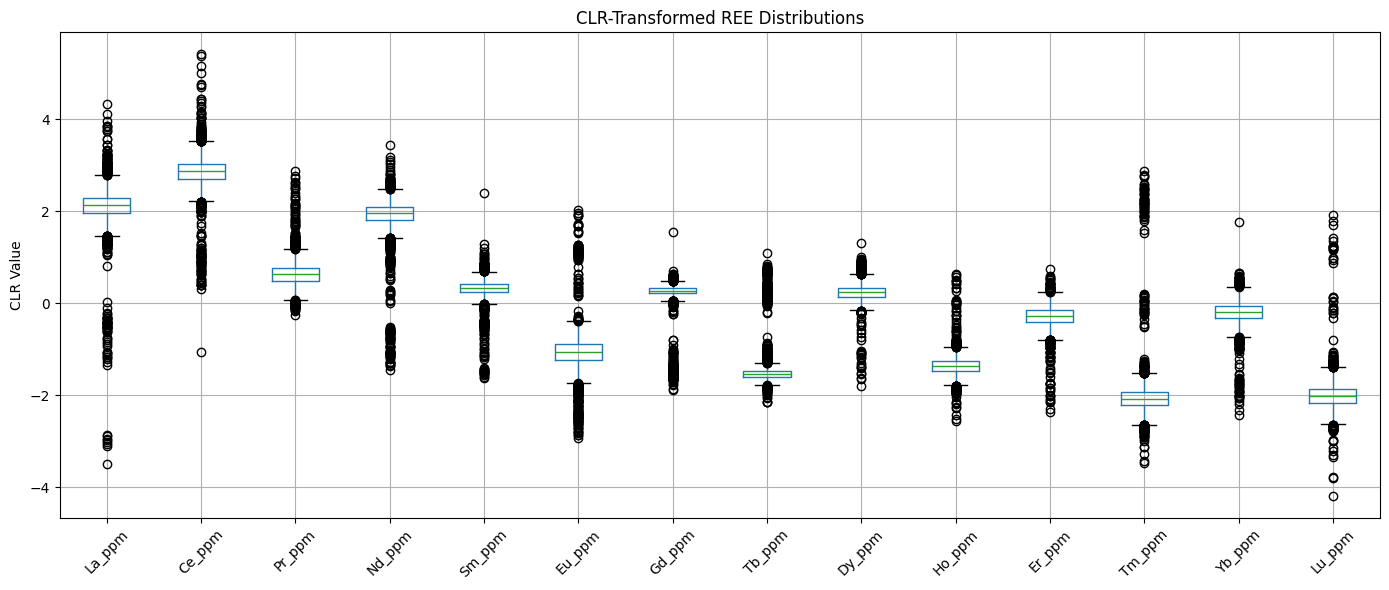

In [25]:

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))

X_clr.boxplot(rot=45)

plt.title("CLR-Transformed REE Distributions")
plt.ylabel("CLR Value")
plt.tight_layout()
plt.show()

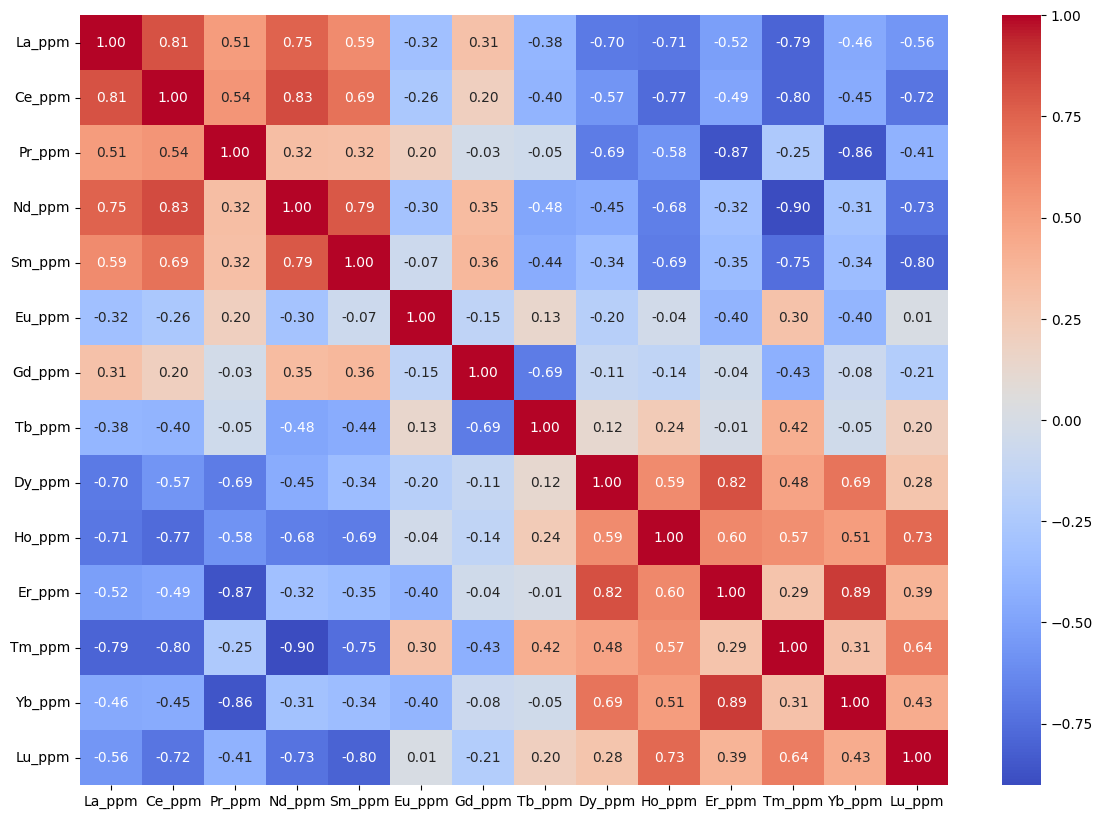

In [26]:
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(X_clr.corr(),annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

## 9. Feature Scaling

The CLR-transformed REE features are standardized using StandardScaler.

Standardization ensures that the features are placed on a comparable scale before applying distance- and distribution-based anomaly detection algorithms.

In [27]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_scale = ss.fit_transform(X_clr)

X_scale = pd.DataFrame(X_scale, columns=ree_cols, index=X_clr.index)
X_scale.head()

,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
0,0.219508,0.869852,0.290768,0.395740,0.568897,0.574553,0.525628,-0.117967,-0.664377,-0.433482,-0.590592,-0.502973,-0.702295,-1.008562
1,-0.031430,0.564583,-0.186980,0.141500,0.157789,0.837467,0.336327,-0.202673,-0.471687,-0.083292,-0.110755,-0.196882,-0.333300,-0.832498
2,-0.162670,0.591835,-0.062539,0.208704,0.360769,0.852907,0.344070,-0.191920,-0.611481,-0.248389,-0.335392,-0.255410,-0.292262,-0.625373
3,-0.276471,0.825292,-0.221377,0.087308,0.243085,0.753582,0.268350,-0.298225,-0.581931,-0.145815,-0.324794,-0.188331,-0.099904,-0.390612
4,0.310338,0.397423,0.300438,0.494485,0.496644,1.267167,0.461224,-0.202758,-0.733159,-0.308570,-0.558253,-0.533466,-0.904174,-1.224763


In [28]:
print(X_scale.mean().round(4))
print(X_scale.std().round(4))

La_ppm   -0.0
Ce_ppm   -0.0
Pr_ppm    0.0
Nd_ppm   -0.0
Sm_ppm   -0.0
Eu_ppm   -0.0
Gd_ppm   -0.0
Tb_ppm    0.0
Dy_ppm   -0.0
Ho_ppm    0.0
Er_ppm   -0.0
Tm_ppm   -0.0
Yb_ppm   -0.0
Lu_ppm   -0.0
dtype: float64
La_ppm    1.0
Ce_ppm    1.0
Pr_ppm    1.0
Nd_ppm    1.0
Sm_ppm    1.0
Eu_ppm    1.0
Gd_ppm    1.0
Tb_ppm    1.0
Dy_ppm    1.0
Ho_ppm    1.0
Er_ppm    1.0
Tm_ppm    1.0
Yb_ppm    1.0
Lu_ppm    1.0
dtype: float64


## 10. Anomaly Detection — Isolation Forest

Isolation Forest is applied as a global anomaly detection method.

The algorithm identifies observations that are easier to isolate from the majority of the dataset and therefore potentially represent unusual geochemical samples.

In [29]:
from sklearn.ensemble import IsolationForest

is_forest = IsolationForest(n_estimators=300, contamination='auto', random_state=42, n_jobs=-1)

is_forest.fit(X_scale)
if_prediction = is_forest.predict(X_scale)
if_score = is_forest.decision_function(X_scale)


In [30]:
results = df.copy()

results["IF_Prediction"] = if_prediction
results["IF_Anomaly"] = results["IF_Prediction"] == -1
results["IF_Score"] = if_score

In [58]:
results['IF_Prediction'].unique()

array([ 1, -1])

In [31]:
results.head()

,FID,Shape *,gid,objectid,sampleno,X,Y,Si02_%,Al2O3_%,Fe2O3_%,...,Pt_ppb,Pd_ppb,In_ppm,F_ppm,Te_ppm,Tl_ppm,toposheet,IF_Prediction,IF_Anomaly,IF_Score
0,0,Point,129,129,57E02/081/SS/00,77.194444,15.599099,60.03,11.96,4.81,...,0.0,0.0,0.0,0.0,0.0,0.0,57E02,1,False,0.124156
1,1,Point,130,130,57E02/082/SS/00,77.212963,15.599099,58.85,11.96,4.91,...,0.0,0.0,0.0,0.0,0.0,0.0,57E02,1,False,0.128355
2,2,Point,131,131,57E02/083/SS/00,77.231481,15.599099,65.12,11.06,4.33,...,0.0,0.0,0.0,0.0,0.0,0.0,57E02,1,False,0.132141
3,3,Point,132,132,57E02/084/SS/00,77.250000,15.599099,65.63,10.94,4.88,...,0.0,0.0,0.0,0.0,0.0,0.0,57E02,1,False,0.125902
4,4,Point,133,133,57E02/085/SS/00,77.009259,15.617117,54.15,12.38,4.98,...,0.0,0.0,0.0,0.0,0.0,0.0,57E02,1,False,0.116301


In [32]:
results['IF_Anomaly'].value_counts()

IF_Anomaly
False    9116
True      888
Name: count, dtype: int64

In [33]:
print(
    "Isolation Forest anomalies:",
    results["IF_Anomaly"].sum()
)

Isolation Forest anomalies: 888


## 11. Anomaly Detection — Local Outlier Factor (LOF)

Local Outlier Factor (LOF) identifies observations that have substantially lower local density than their neighboring observations.

Unlike global anomaly detection methods, LOF is particularly useful for identifying samples that are unusual relative to their local geochemical neighborhood.

In [34]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination='auto', n_jobs=-1)
lof_prediction = lof.fit_predict(X_scale)

lof_score = lof.negative_outlier_factor_


In [35]:
results["LOF_Prediction"] = lof_prediction
results["LOF_Anomaly"] = results["LOF_Prediction"] == -1
results["LOF_Score"] = lof_score

In [36]:
results["LOF_Anomaly"].sum()

np.int64(546)

## 12. Anomaly Detection — One-Class SVM

One-Class Support Vector Machine is used as an additional unsupervised anomaly detection method.

The model attempts to learn the boundary of the normal observations and identifies samples that fall outside this learned region.

In [37]:
from sklearn.svm import OneClassSVM

onsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

onsvm_prediction = onsvm.fit_predict(X_scale)
onsvm_score = onsvm.decision_function(X_scale)

In [38]:
results["OCSVM_Prediction"] = onsvm_prediction
results["OCSVM_Anomaly"] = results["OCSVM_Prediction"] == -1
results["OCSVM_Score"] = onsvm_score

In [39]:
results.head()

,FID,Shape *,gid,objectid,sampleno,X,Y,Si02_%,Al2O3_%,Fe2O3_%,...,toposheet,IF_Prediction,IF_Anomaly,IF_Score,LOF_Prediction,LOF_Anomaly,LOF_Score,OCSVM_Prediction,OCSVM_Anomaly,OCSVM_Score
0,0,Point,129,129,57E02/081/SS/00,77.194444,15.599099,60.03,11.96,4.81,...,57E02,1,False,0.124156,1,False,-1.119879,1,False,14.005928
1,1,Point,130,130,57E02/082/SS/00,77.212963,15.599099,58.85,11.96,4.91,...,57E02,1,False,0.128355,1,False,-1.093832,1,False,12.216885
2,2,Point,131,131,57E02/083/SS/00,77.231481,15.599099,65.12,11.06,4.33,...,57E02,1,False,0.132141,1,False,-1.006381,1,False,12.663598
3,3,Point,132,132,57E02/084/SS/00,77.250000,15.599099,65.63,10.94,4.88,...,57E02,1,False,0.125902,1,False,-1.084363,1,False,11.677794
4,4,Point,133,133,57E02/085/SS/00,77.009259,15.617117,54.15,12.38,4.98,...,57E02,1,False,0.116301,1,False,-1.174927,1,False,9.077352


In [40]:
print(
    "One-Class SVM anomalies:",
    results["OCSVM_Anomaly"].sum()
)

One-Class SVM anomalies: 499


## 13. Comparison of Anomaly Detection Models

The predictions from Isolation Forest, LOF, and One-Class SVM are compared.

The objective is not simply to select the model producing the largest number of anomalies, but to examine the level of agreement and disagreement among different anomaly detection approaches.

In [41]:
model_comparison = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "LOF",
        "One-Class SVM"
    ],
    "Anomalies": [
        results["IF_Anomaly"].sum(),
        results["LOF_Anomaly"].sum(),
        results["OCSVM_Anomaly"].sum()
    ],
    "Percentage": [
        results["IF_Anomaly"].mean() * 100,
        results["LOF_Anomaly"].mean() * 100,
        results["OCSVM_Anomaly"].mean() * 100
    ]
})

display(model_comparison)

,Model,Anomalies,Percentage
0,Isolation Forest,888,8.876449
1,LOF,546,5.457817
2,One-Class SVM,499,4.988005


In [42]:
agreement = pd.crosstab(
    results["IF_Anomaly"],
    results["LOF_Anomaly"],
    rownames=["Isolation Forest"],
    colnames=["LOF"]
)

display(agreement)

LOF,False,True
Isolation Forest,,
False,8684,432
True,774,114


In [43]:
agreement_all = results[
    [
        "IF_Anomaly",
        "LOF_Anomaly",
        "OCSVM_Anomaly"
    ]
].value_counts().reset_index(name="Count")

display(agreement_all)

,IF_Anomaly,LOF_Anomaly,OCSVM_Anomaly,Count
0,False,False,False,8645
1,True,False,False,482
2,False,True,False,372
3,True,False,True,292
4,True,True,True,108
5,False,True,True,60
6,False,False,True,39
7,True,True,False,6


## 14. Investigation of LOF-Only Anomalies

Samples identified as anomalies by LOF but not by Isolation Forest are investigated separately.

These samples are particularly interesting because they may represent local geochemical anomalies that are not sufficiently extreme to be detected by a more global method.

In [44]:
lof_only = results[
    (results["LOF_Anomaly"]) &
    (~results["IF_Anomaly"])
]

print(
    "Number of LOF-only anomalies:",
    len(lof_only)
)

display(
    lof_only[
        [
            "sampleno",
            "X",
            "Y",
            "toposheet",
            "LOF_Score",
            "IF_Score"
        ]
    ].head(20)
)

Number of LOF-only anomalies: 432


,sampleno,X,Y,toposheet,LOF_Score,IF_Score
186,57E04/016/SS/11,77.027778,15.027111,57E04,-1.949481,0.079643
197,57E04/152/SS/11,77.212963,15.189687,57E04,-1.656127,0.007753
204,57E04/159/SS/11,77.083333,15.207848,57E04,-1.552672,0.051881
218,57E02/140/SS/00,77.250000,15.671171,57E02,-1.656656,0.009604
310,57E04/037/SS/11,77.157407,15.045133,57E04,-1.895881,0.077230
312,57E04/039/SS/11,77.194444,15.045104,57E04,-2.224737,0.011168
316,57E04/043/SS/11,77.009259,15.063263,57E04,-2.140099,0.024474
323,57E04/050/SS/11,77.138889,15.063220,57E04,-2.982076,0.026006
343,57E04/070/SS/11,77.250000,15.081201,57E04,-1.605205,0.101451
476,57E04/005/SS/11,77.083333,15.009045,57E04,-1.529347,0.134463


In [45]:
if len(lof_only) == 0:
    print(
        "No LOF-only anomaly was found with the current settings."
    )
else:
    sample_index = lof_only.index[0]

    print("Selected sample index:", sample_index)
    print("Sample number:", results.loc[sample_index, "sampleno"])

Selected sample index: 186
Sample number: 57E04/016/SS/11


In [46]:
raw_sample = X_imputed.loc[sample_index]

raw_sample_df = raw_sample.to_frame(
    name="Raw_REE_Concentration_ppm"
)

display(raw_sample_df)

,Raw_REE_Concentration_ppm
La_ppm,31.323000
Ce_ppm,63.459999
Pr_ppm,7.192000
Nd_ppm,26.042999
Sm_ppm,4.970000
Eu_ppm,1.058000
Gd_ppm,4.926000
Tb_ppm,0.788000
Dy_ppm,5.212000
Ho_ppm,0.889000


In [47]:
clr_sample = X_clr.loc[sample_index]

clr_sample_df = clr_sample.to_frame(
    name="CLR_Value"
)

display(clr_sample_df)

,CLR_Value
La_ppm,2.180539
Ce_ppm,2.886596
Pr_ppm,0.709155
Nd_ppm,1.995935
Sm_ppm,0.339606
Eu_ppm,-1.207434
Gd_ppm,0.330713
Tb_ppm,-1.502071
Dy_ppm,0.387150
Ho_ppm,-1.381472


In [48]:
comparison = pd.DataFrame({
    "Selected_Sample": X_imputed.loc[sample_index],
    "Dataset_Median": X_imputed.median(),
    "Dataset_Mean": X_imputed.mean(),
    "Dataset_Min": X_imputed.min(),
    "Dataset_Max": X_imputed.max()
})

display(comparison)

,Selected_Sample,Dataset_Median,Dataset_Mean,Dataset_Min,Dataset_Max
La_ppm,31.323000,28.713138,34.121074,0.150000,1558.340000
Ce_ppm,63.459999,60.330000,70.958303,0.867000,3605.180000
Pr_ppm,7.192000,6.413446,7.487577,0.379778,186.220000
Nd_ppm,26.042999,24.198913,27.397156,0.250000,496.860000
Sm_ppm,4.970000,4.807815,5.309225,0.148805,72.331327
Eu_ppm,1.058000,1.213554,1.314629,0.040068,33.158001
Gd_ppm,4.926000,4.507436,4.896819,0.250000,68.405298
Tb_ppm,0.788000,0.751458,0.968083,0.046944,13.040000
Dy_ppm,5.212000,4.368928,4.874461,0.206960,71.994459
Ho_ppm,0.889000,0.870000,0.989726,0.052620,13.479745


## 16. Local Neighborhood Analysis

The nearest neighboring samples are identified using the standardized CLR-transformed REE features.

The selected anomaly is then compared with its local neighbors to determine whether its chemical composition differs substantially from the surrounding geochemical population.

In [49]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=11)

knn.fit(X_scale)

distances, indices = knn.kneighbors(
    X_scale.loc[[sample_index]]
)

neighbor_indices = X_scale.index[indices[0]]

print("Selected sample:", sample_index)
print("Nearest neighbors:")

display(
    results.loc[
        neighbor_indices,
        ["sampleno", "X", "Y", "toposheet"]
    ]
)

Selected sample: 186
Nearest neighbors:


,sampleno,X,Y,toposheet
186,57E04/016/SS/11,77.027778,15.027111,57E04
488,57E04/022/SS/11,77.138889,15.027070,57E04
8717,57C9/119/S/15,76.620290,13.903650,57C09
6671,57A03/094/S/14,76.176970,15.367480,57A03
297,57E04/024/SS/11,77.175926,15.027044,57E04
474,57E04/003/SS/11,77.046296,15.009046,57E04
7790,57A2/060/S/14,76.065270,15.581330,57A02
324,57E04/051/SS/11,77.157407,15.063208,57E04
6059,57B11/195/S/2012,76.731667,14.493333,57B11
1463,57E11/190/SS/05,77.638889,15.493243,57E11


In [50]:
neighbor_chemistry = X_imputed.loc[neighbor_indices]

display(neighbor_chemistry)

,La_ppm,Ce_ppm,Pr_ppm,Nd_ppm,Sm_ppm,Eu_ppm,Gd_ppm,Tb_ppm,Dy_ppm,Ho_ppm,Er_ppm,Tm_ppm,Yb_ppm,Lu_ppm
186,31.323000,63.459999,7.192000,26.042999,4.970000,1.058000,4.926000,0.788000,5.212000,0.889000,3.180000,0.250000,3.307000,0.522000
488,30.334000,63.500999,7.062000,24.316999,5.034000,1.100000,4.957000,0.774000,5.127000,0.824000,2.984000,0.250000,3.119000,0.505000
8717,27.649000,49.329000,5.433000,20.417000,3.870000,0.839000,3.883000,0.669000,3.994000,0.724000,2.301000,0.298000,2.614000,0.443000
6671,19.252934,51.419460,5.119708,20.058680,3.565956,0.933530,3.767629,0.585353,3.827559,0.666342,2.491686,0.145219,1.876947,0.382846
297,19.353001,40.943001,4.484000,15.864000,3.213000,0.700000,3.195000,0.507000,3.308000,0.549000,2.002000,0.250000,2.133000,0.250000
474,19.971001,40.389999,4.630000,16.646000,3.274000,0.722000,3.237000,0.530000,3.483000,0.582000,2.083000,0.250000,2.201000,0.250000
7790,40.071307,110.575576,9.638201,35.165247,6.801191,1.477131,6.613705,1.124137,7.169419,1.333895,3.721533,0.515392,4.200931,0.726780
324,19.459000,40.589001,4.552000,14.991000,3.236000,0.704000,3.196000,0.502000,3.298000,0.542000,2.008000,0.250000,2.263000,0.250000
6059,25.899932,43.527332,5.805677,21.056064,3.883795,0.861148,3.815519,0.598276,3.965799,0.672141,2.219234,0.326945,2.449377,0.355379
1463,41.737999,79.180441,9.463000,36.181000,7.455000,1.341000,7.063000,1.219000,6.889000,1.574000,4.575000,0.494000,5.000000,0.734000


In [51]:
neighbor_median = neighbor_chemistry.median()

neighbor_comparison = pd.DataFrame({
    "Selected_Sample": X_imputed.loc[sample_index],
    "Neighbor_Median": neighbor_median
})

neighbor_comparison["Ratio_to_Neighbor_Median"] = (
    neighbor_comparison["Selected_Sample"] /
    neighbor_comparison["Neighbor_Median"]
)

display(neighbor_comparison)

,Selected_Sample,Neighbor_Median,Ratio_to_Neighbor_Median
La_ppm,31.323000,25.899932,1.209385
Ce_ppm,63.459999,49.329000,1.286464
Pr_ppm,7.192000,5.433000,1.323762
Nd_ppm,26.042999,20.417000,1.275555
Sm_ppm,4.970000,3.870000,1.284238
Eu_ppm,1.058000,0.861148,1.228593
Gd_ppm,4.926000,3.815519,1.291043
Tb_ppm,0.788000,0.598276,1.317118
Dy_ppm,5.212000,3.965799,1.314237
Ho_ppm,0.889000,0.672141,1.322639


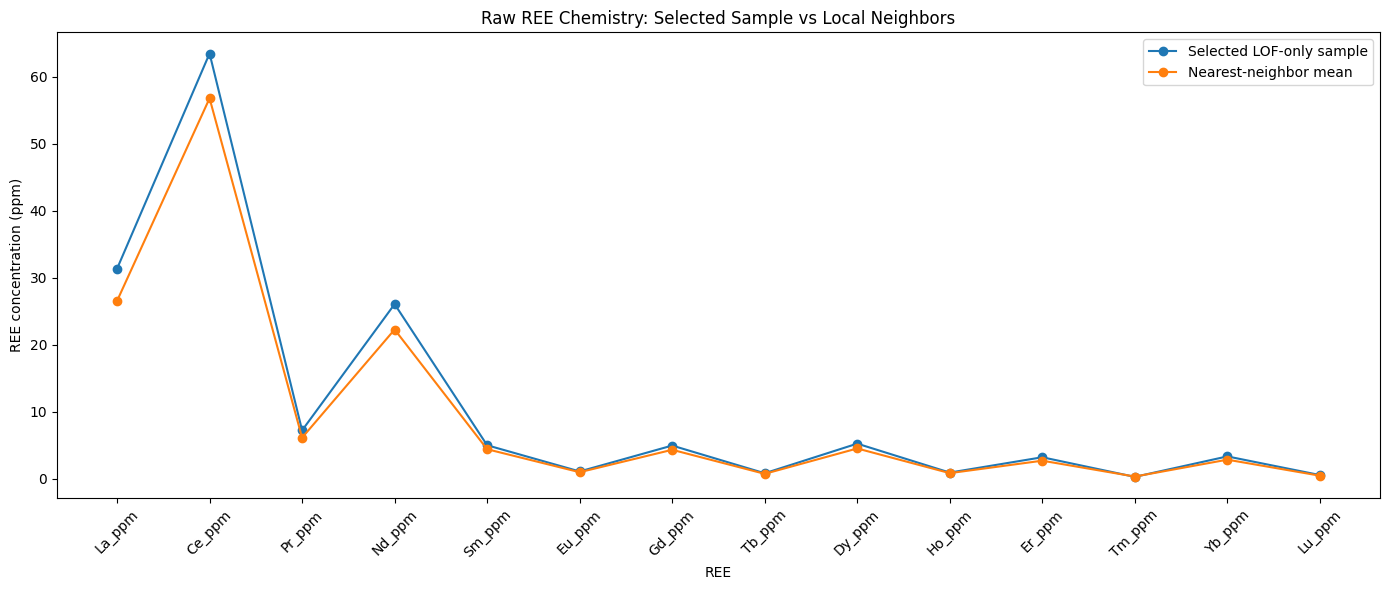

In [52]:
plt.figure(figsize=(14, 6))

plt.plot(
    ree_cols,
    X_imputed.loc[sample_index],
    marker="o",
    label="Selected LOF-only sample"
)

neighbor_mean = X_imputed.loc[
    neighbor_indices
].mean()

plt.plot(
    ree_cols,
    neighbor_mean,
    marker="o",
    label="Nearest-neighbor mean"
)

plt.xticks(rotation=45)
plt.ylabel("REE concentration (ppm)")
plt.xlabel("REE")
plt.title("Raw REE Chemistry: Selected Sample vs Local Neighbors")
plt.legend()

plt.tight_layout()
plt.show()

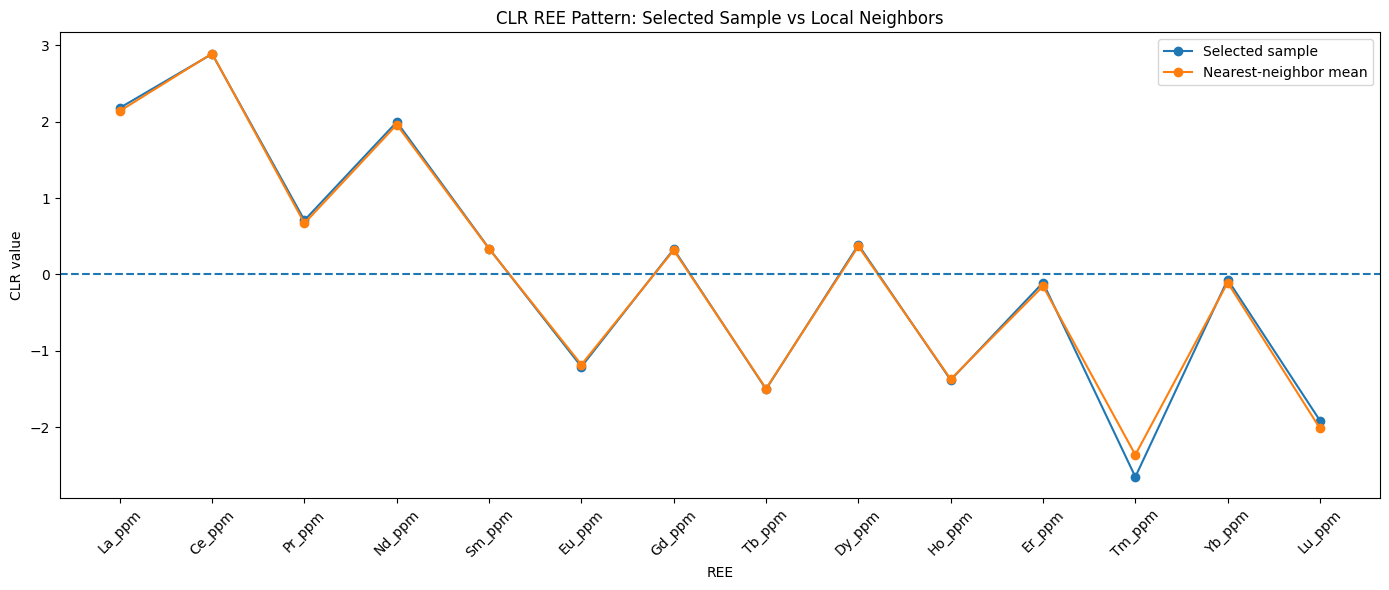

In [53]:
plt.figure(figsize=(14, 6))

plt.plot(
    ree_cols,
    X_clr.loc[sample_index],
    marker="o",
    label="Selected sample"
)

neighbor_clr_mean = X_clr.loc[
    neighbor_indices
].mean()

plt.plot(
    ree_cols,
    neighbor_clr_mean,
    marker="o",
    label="Nearest-neighbor mean"
)

plt.axhline(0, linestyle="--")

plt.xticks(rotation=45)
plt.ylabel("CLR value")
plt.xlabel("REE")
plt.title("CLR REE Pattern: Selected Sample vs Local Neighbors")
plt.legend()

plt.tight_layout()
plt.show()

In [54]:
neighbor_diff = (
    X_clr.loc[sample_index] -
    X_clr.loc[neighbor_indices].mean()
)

neighbor_diff = neighbor_diff.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

display(
    neighbor_diff.to_frame(
        "CLR Difference from Neighbor Mean"
    )
)

,CLR Difference from Neighbor Mean
Tm_ppm,-0.288791
Lu_ppm,0.101647
Er_ppm,0.046924
La_ppm,0.041077
Pr_ppm,0.039098
Yb_ppm,0.038983
Nd_ppm,0.034754
Eu_ppm,-0.026311
Dy_ppm,0.018342
Gd_ppm,0.013082


## 18. Anomaly Case Study and Geochemical Interpretation

The final selected sample is examined as an individual anomaly case.

The analysis combines:
- Anomaly detection results
- Raw REE concentrations
- CLR-transformed values
- Dataset-level statistics
- Local neighboring samples

This provides a more interpretable basis for determining why the sample was classified as anomalous.

In [55]:
print("=" * 60)
print("ANOMALY CASE STUDY")
print("=" * 60)

print("Sample index:", sample_index)
print("Sample number:", results.loc[sample_index, "sampleno"])

print(
    "Isolation Forest:",
    "Anomaly" if results.loc[sample_index, "IF_Anomaly"]
    else "Normal"
)

print(
    "LOF:",
    "Anomaly" if results.loc[sample_index, "LOF_Anomaly"]
    else "Normal"
)

print(
    "One-Class SVM:",
    "Anomaly" if results.loc[sample_index, "OCSVM_Anomaly"]
    else "Normal"
)

print("LOF score:", results.loc[sample_index, "LOF_Score"])
print("IF score:", results.loc[sample_index, "IF_Score"])

ANOMALY CASE STUDY
Sample index: 186
Sample number: 57E04/016/SS/11
Isolation Forest: Normal
LOF: Anomaly
One-Class SVM: Normal
LOF score: -1.9494808498407683
IF score: 0.07964320062222346


# 19. Conclusion

This analysis demonstrates an unsupervised machine learning workflow for detecting anomalous REE geochemical samples.

Three anomaly detection approaches—Isolation Forest, Local Outlier Factor, and One-Class SVM—were applied to CLR-transformed and standardized REE data.

The comparison of multiple models helps identify both globally unusual and locally unusual samples. Particular attention was given to LOF-only anomalies because they may represent samples whose chemical composition is unusual relative to their local neighborhood rather than being extreme at the dataset level.

The final anomaly case study combines machine learning results with raw REE chemistry and neighboring-sample analysis to provide a more interpretable geochemical assessment.

## Key Findings

- Number of samples analyzed: `...`
- Number of REE features: `...`
- Isolation Forest anomalies: `...`
- LOF anomalies: `...`
- One-Class SVM anomalies: `...`
- LOF-only anomalies investigated: `...`

## Limitations

The detected anomalies should not automatically be interpreted as mineralization or geological anomalies. Machine learning identifies statistical/geochemical unusualness; geological validation requires domain knowledge and, where available, independent geological or mineralogical evidence.